#  Introduction to the surface code

- **Author**: Théo HUET
- **Date**: 18/09/2026-20/09/2026

Implementation and Verification of a $d=3$ Planar Surface Code using **Qiskit**.

The objective of this notebook is to implement a distance-3 ($d=3$) planar surface code to encode $1$ logical qubit using $17$ physical qubits ($9$ data qubits and $8$ ancilla qubits for measurement). Drawing on the theoretical framework from Cleland's "An introduction to the surface code", the goal is to successfully initialize a logical state (e.g., $\vert{}0\rangle_L$), artificially inject single-qubit Pauli errors (Bit-flip $X$, Phase-flip $Z$, or both $Y$) on targeted data qubits, and extract the error syndrome via non-destructive parity measurements of the $X$-stabilizer and $Z$-stabilizer plaquettes. Finally, the notebook will implement a classical decoding routine (Look-up Table) to map the extracted syndrome to the most probable physical error, apply the corresponding correction, and verify the perfect preservation of the logical quantum state.

In [74]:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

In [75]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [76]:
d = 3
nbr_logical_qubits = 1

global nbr_data_qubits, nbr_ancilla_qubits, nbr_ancilla_x, nbr_ancilla_z

nbr_data_qubits = d*d #9
nbr_ancilla_qubits = nbr_data_qubits - nbr_logical_qubits #8

nbr_ancilla_x = nbr_ancilla_qubits // 2 #4
nbr_ancilla_z = nbr_ancilla_qubits - nbr_ancilla_x #4

# Statement of the registers

In [77]:
def init_registers():
  q_data = QuantumRegister(nbr_data_qubits, name="data")

  q_anc_z = QuantumRegister(nbr_ancilla_z, name="ancilla_z")
  q_anc_x = QuantumRegister(nbr_ancilla_x, name="ancilla_x")

  #classic bit
  c_syndrome_z = ClassicalRegister(nbr_ancilla_z, name="syndrome_z")
  c_syndrome_x = ClassicalRegister(nbr_ancilla_x, name="syndrome_x")

  return q_data, q_anc_z, q_anc_x, c_syndrome_z, c_syndrome_x

# The Circuit

In [78]:
def stabilizer_circuit(qc):# Init Circuit
  # Z-Stabilizer Generation
  map_Z = {
      0: [0,1,3,4],
      1: [4,5,7,8],
      2: [1,2],
      3: [6,7]
  }
  # separation
  qc.barrier(label="Z-Stabilizer")

  for anc_Z_idx in range(nbr_ancilla_z):
    for data_idx in map_Z[anc_Z_idx]:
      qc.cx(q_data[data_idx], q_anc_z[anc_Z_idx])

  # X-Stabilizer Generation

  map_X = {
      0: [1,2,4,5],
      1: [3,4,6,7],
      2: [0,3],
      3: [5,8]
  }
  # separation
  qc.barrier(label="X-Stabilizer")

  for anc_X_idx in range(nbr_ancilla_x):
    qc.h(q_anc_x[anc_X_idx])
    for data_idx in map_X[anc_X_idx]:
      qc.cx(q_anc_x[anc_X_idx], q_data[data_idx])
    qc.h(q_anc_x[anc_X_idx])

  # Measuring Syndromes

  # separation
  qc.barrier(label="Measurement")

  qc.measure(q_anc_z, c_syndrome_z)
  qc.measure(q_anc_x, c_syndrome_x)
  return qc

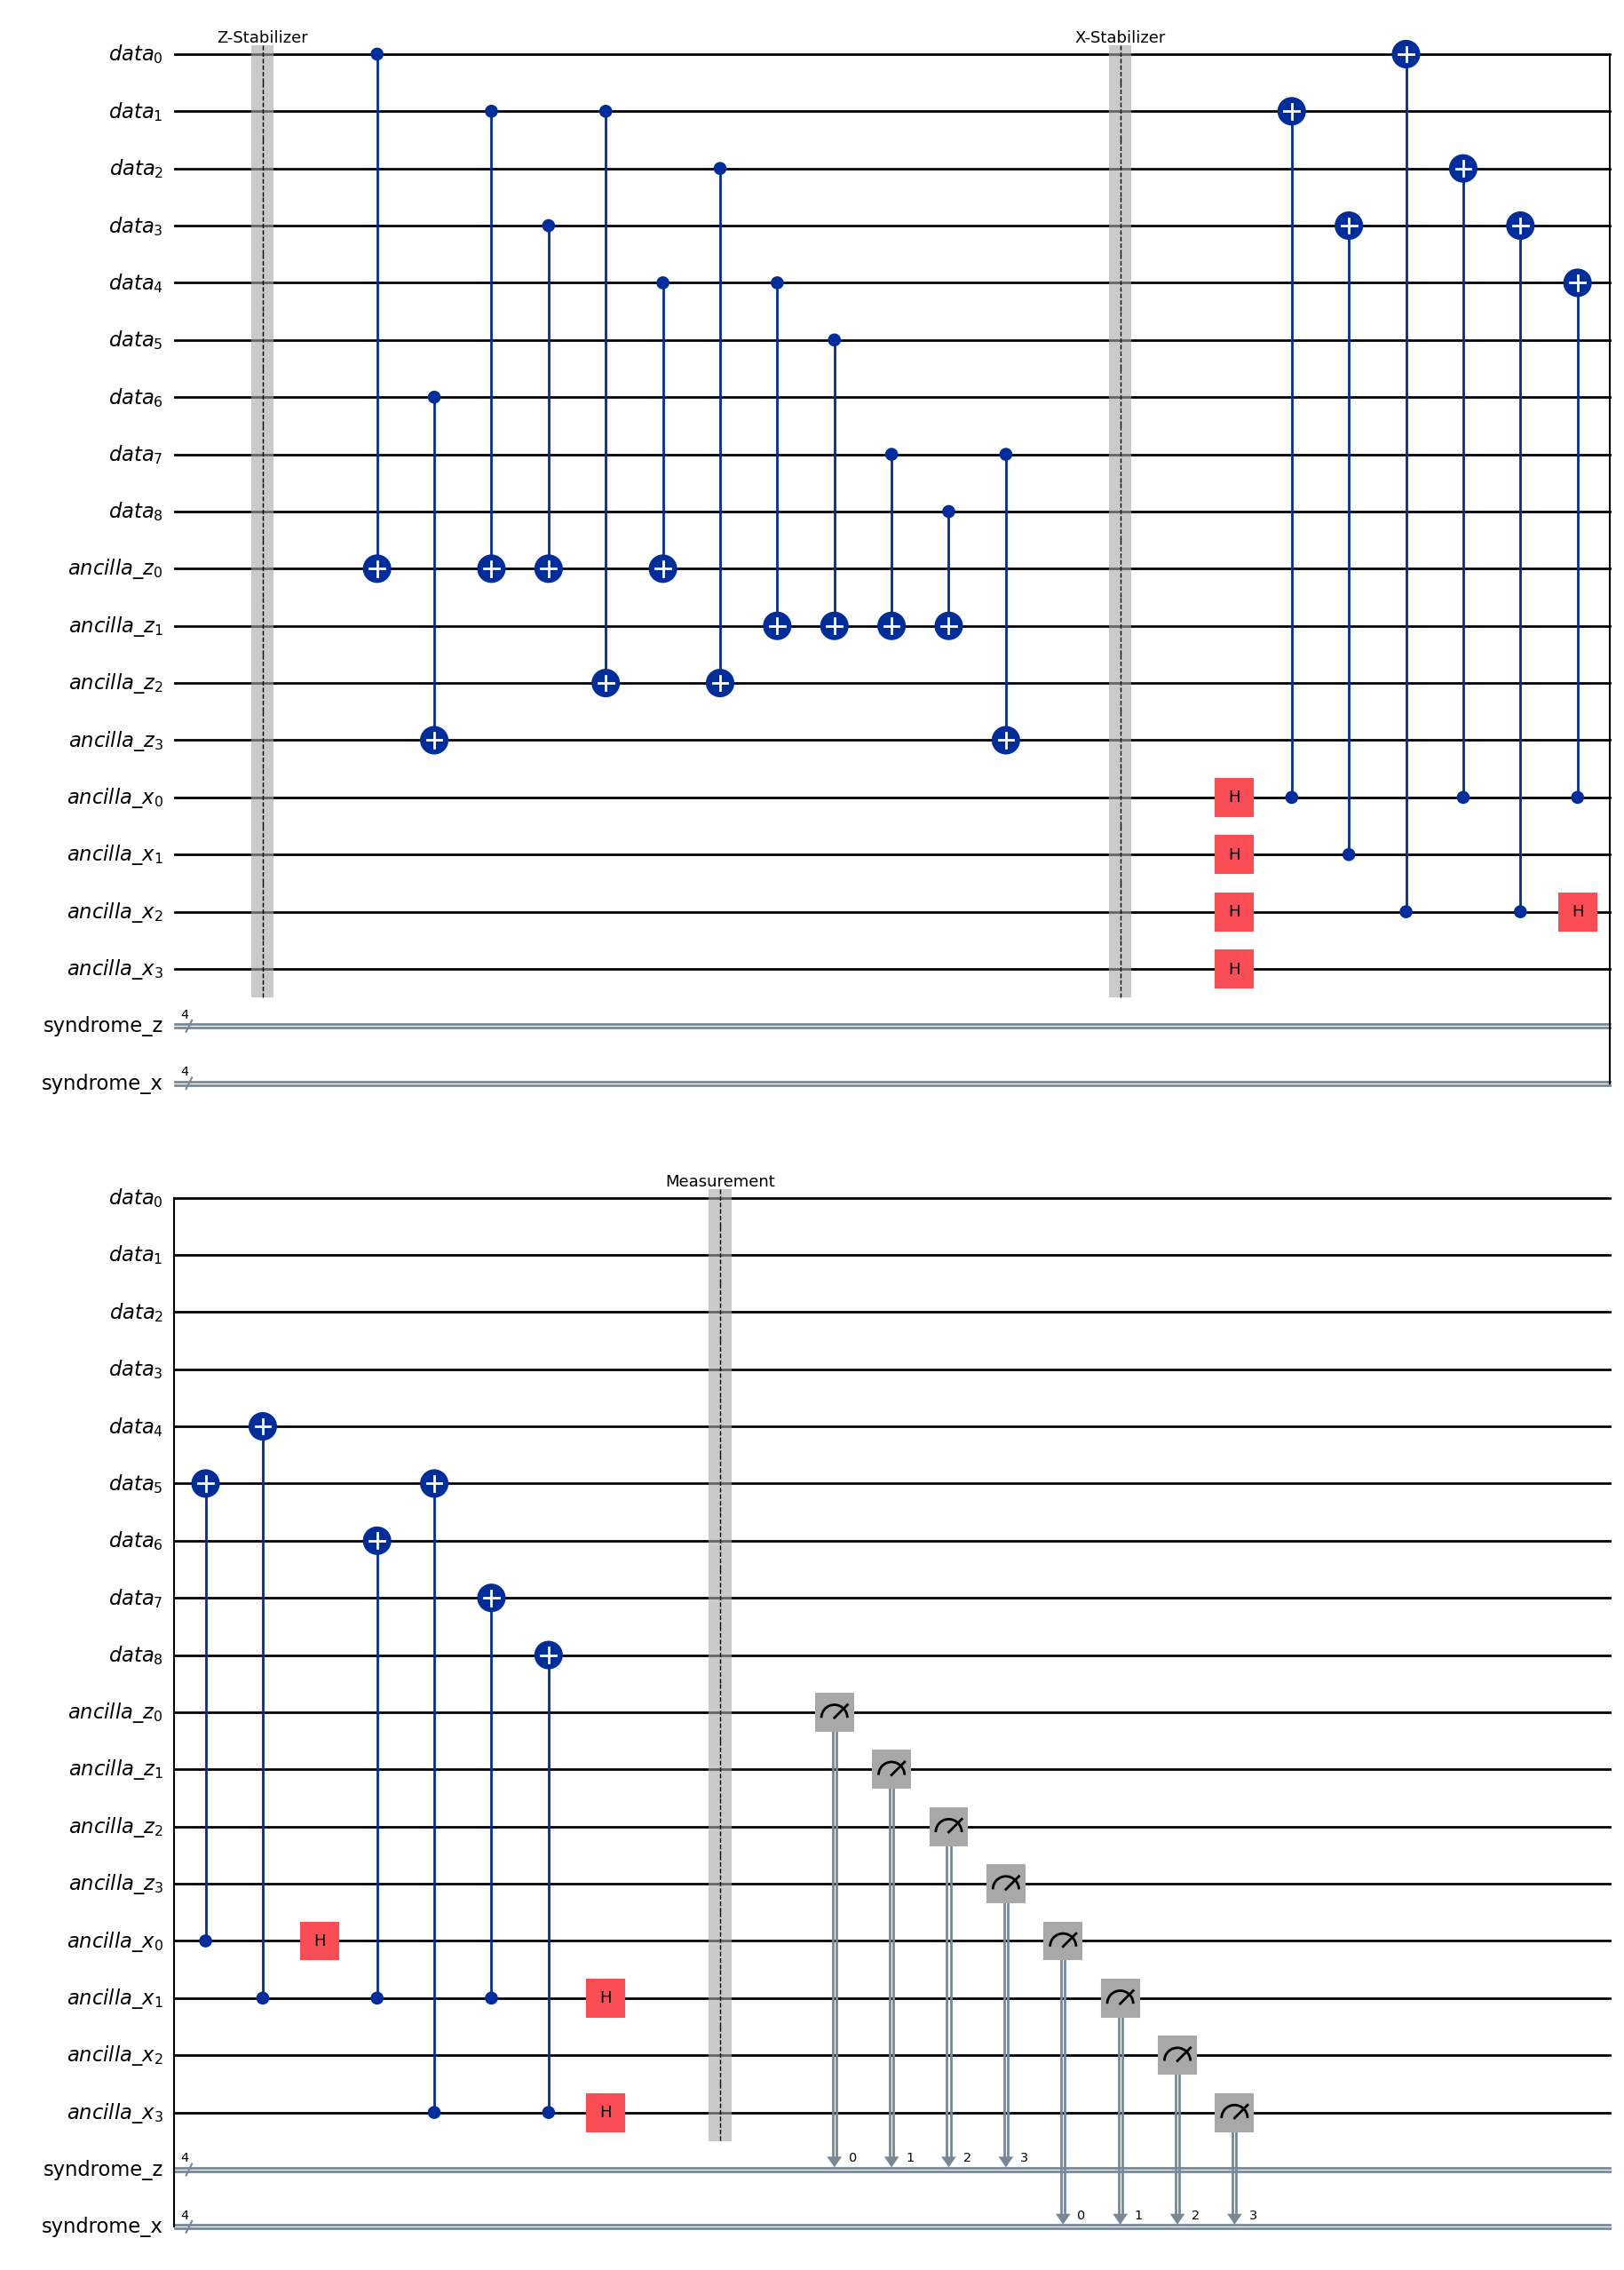

In [79]:
q_data, q_anc_z, q_anc_x, c_syndrome_z, c_syndrome_x = init_registers()
qc = QuantumCircuit(q_data, q_anc_z, q_anc_x, c_syndrome_z, c_syndrome_x, name="stabilizer_circuit")

qc_stabilizer = stabilizer_circuit(qc)
qc_stabilizer.draw(output="mpl", style="iqp")

---

# add Error

In [80]:
def build_surface_code_circuit(errors_to_inject=[], init_basis='Z'):
  """
  errors_to_inject: liste de tuples (type_erreur, index_qubit)
  Exemple: [('X', 4), ('Z', 1)]
  """
  q_data, q_anc_z, q_anc_x, c_syndrome_z, c_syndrome_x = init_registers()
  qc = QuantumCircuit(q_data, q_anc_z, q_anc_x, c_syndrome_z, c_syndrome_x, name="stabilizer_circuit")

  if init_basis == 'X':
    qc.barrier(label="State Prep")
    qc.h(q_data) # Bascule tous les data qubits dans l'état |+>

  qc.barrier(label="Error Injection")
  for error in errors_to_inject:
    if error[0] == 'X':
      qc.x(q_data[error[1]])
    elif error[0] == 'Z':
      qc.z(q_data[error[1]])

  qc = stabilizer_circuit(qc)

  return qc


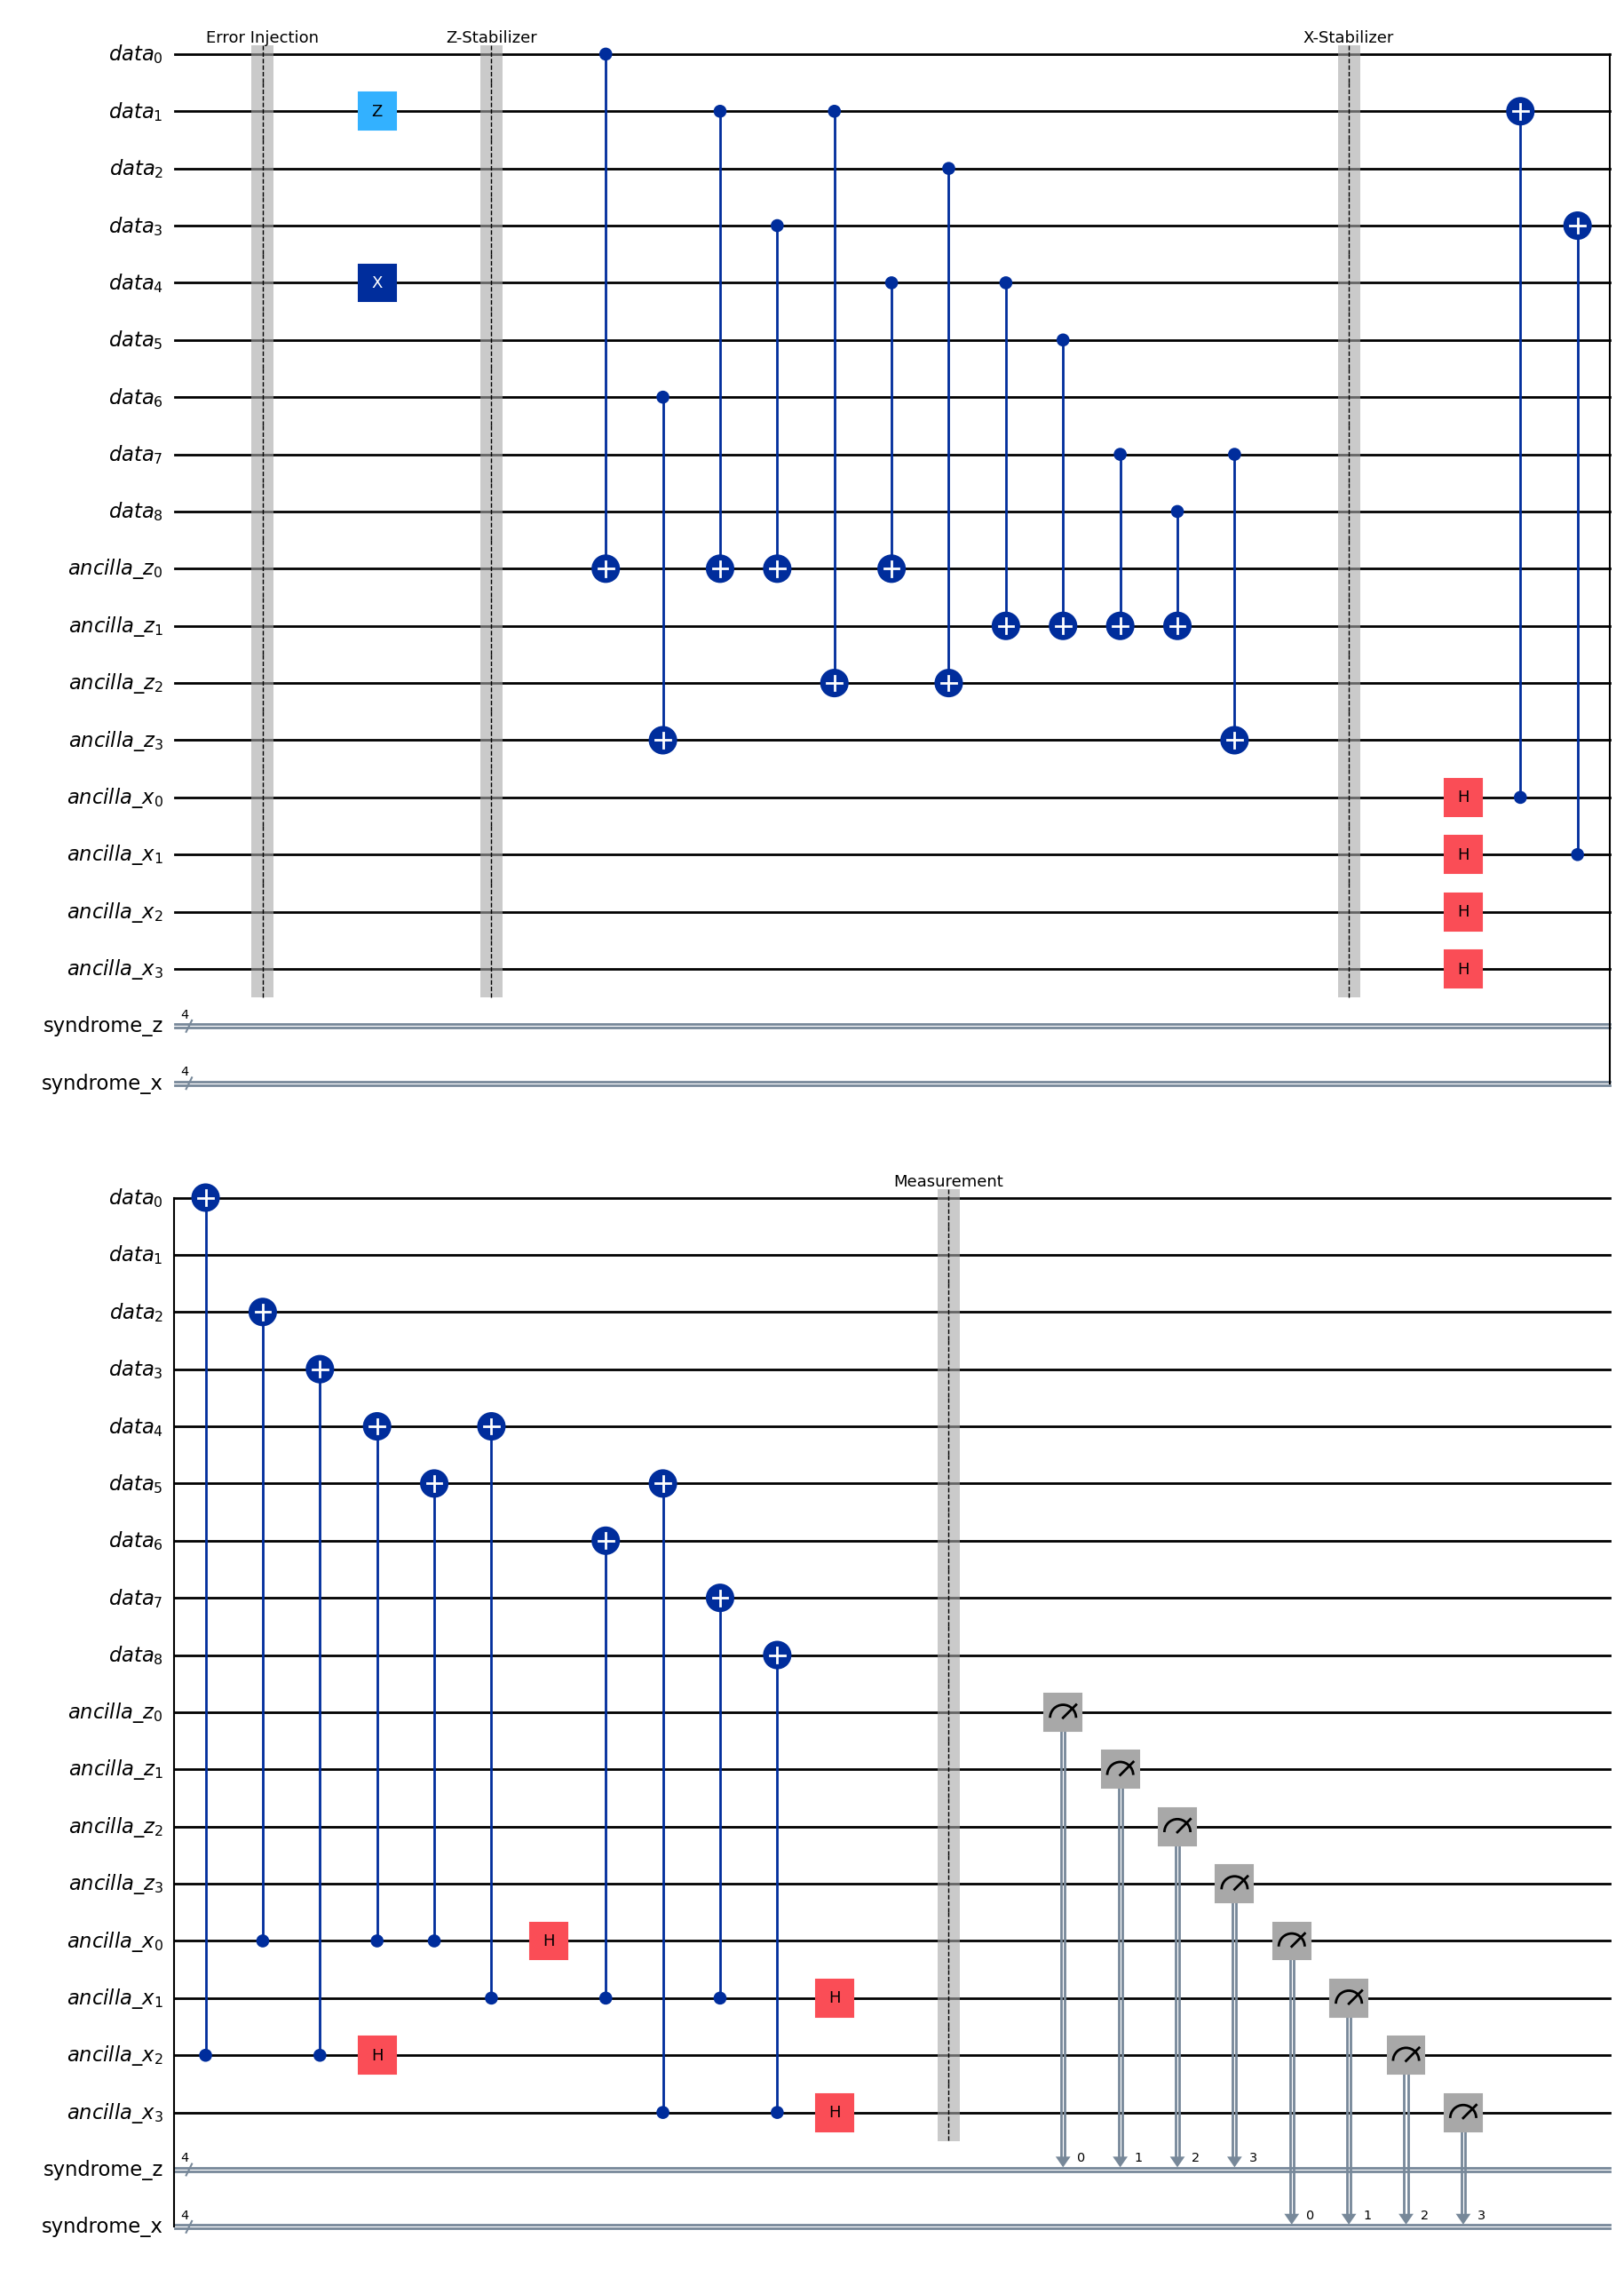

In [81]:
qc = build_surface_code_circuit(errors_to_inject=[('X', 4), ('Z', 1)])
qc.draw(output="mpl", style="iqp")

---
# Simulation

In [82]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

In [83]:
def simulate_surface_code(errors_to_inject=[], shots=1000, init_basis='Z'):
  qc = build_surface_code_circuit(errors_to_inject, init_basis)

  simulator = AerSimulator()

  compiled_circuit = transpile(qc, simulator)

  job = simulator.run(compiled_circuit, shots=shots)
  result = job.result()

  counts = result.get_counts()
  return counts

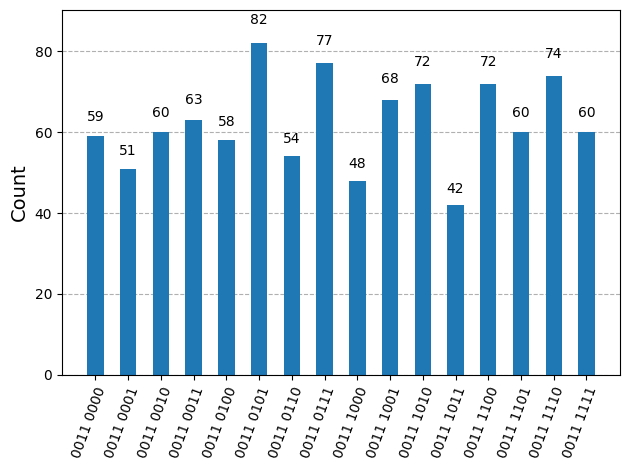

In [84]:
counts = simulate_surface_code(errors_to_inject=[('Z', 4)], shots=1000, init_basis='X')
plot_histogram(counts)

$X_3 X_2 X_1 X_0 \quad Z_3 Z_2 Z_1 Z_0$

---

# Decoding and correction

In [ ]:
LOOKUP_TABLE = {
    # Format: ('Syndrome_X', 'Syndrome_Z'): [('Gate', Qubit_idx)]
    ('0000', '0000'): [],

    # X Errors (detected by the Z syndrome)
    ('0000', '0001'): [('X', 0)],
    ('0000', '0101'): [('X', 1)],
    ('0000', '0100'): [('X', 2)],
    ('0000', '0001'): [('X', 3)],
    ('0000', '0011'): [('X', 4)],
    ('0000', '0010'): [('X', 5)],
    ('0000', '1000'): [('X', 6)],
    ('0000', '1010'): [('X', 7)],
    ('0000', '0010'): [('X', 8)],

    # Z Errors (detected by the X syndrome)
    ('0100', '0000'): [('Z', 0)],
    ('0001', '0000'): [('Z', 1)],
    ('0001', '0000'): [('Z', 2)],
    ('0110', '0000'): [('Z', 3)],
    ('0011', '0000'): [('Z', 4)],
    ('1001', '0000'): [('Z', 5)],
    ('0010', '0000'): [('Z', 6)],
    ('0010', '0000'): [('Z', 7)],
    ('1000', '0000'): [('Z', 8)],

    # Y Errors (detected by both syndromes)
    ('0100', '0001'): [('X', 0), ('Z', 0)],
    ('0001', '0101'): [('X', 1), ('Z', 1)],
    ('0001', '0100'): [('X', 2), ('Z', 2)],
    ('0110', '0001'): [('X', 3), ('Z', 3)],
    ('0011', '0011'): [('X', 4), ('Z', 4)],
    ('1001', '0010'): [('X', 5), ('Z', 5)],
    ('0010', '1000'): [('X', 6), ('Z', 6)],
    ('0010', '1010'): [('X', 7), ('Z', 7)],
    ('1000', '0010'): [('X', 8), ('Z', 8)],
}

$XX = \mathbb I$

$ZZ = \mathbb I$

$YY = \mathbb I$

In [ ]:
def apply_correction(qc, q_data, syndrome_x_str, syndrome_z_str):
    key = (syndrome_x_str, syndrome_z_str)

    if key in LOOKUP_TABLE:
        corrections = LOOKUP_TABLE[key]
        for corr_type, qubit_idx in corrections:
            if corr_type == 'X':
                qc.x(q_data[qubit_idx])
            elif corr_type == 'Z':
                qc.z(q_data[qubit_idx])
        print(f"Correction applied: {corrections}")
    else:
        print("error: no correction found")

---

## References

- **An introduction to the surface code**
Andrew N. Cleland
*University of Chicago, Chicago IL 60637, USA*
(SciPost Phys. Lect. Notes 49 (2022) · published 3 May 2022 )

- Yunos EL KADERI's course on **Quantum Computation and Error-Control Codes** (Master 2)

- [IBM Qiskit documentation](https://quantum.cloud.ibm.com/docs/en/guides)

- [Numpy documentation](https://numpy.org/doc/)

- [Matplotlib documentation](https://matplotlib.org/stable/index.html)